# kNN с нуля

Реализация k ближайших соседей с векторизованной матрицей евклидовых расстояний через broadcasting.  
Верификация: сравнение accuracy с `sklearn.neighbors.KNeighborsClassifier` на датасете Wine.  

> Датасет Wine выбран вместо Iris: на Iris модель даёт ~1.0 при любом k, что делает график accuracy vs k неинформативным.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [6]:
class KNN:
    """
    k ближайших соседей для классификации (KNN).
    """

    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        # Запомнить обучающую выборку
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        # Матрица расстояний (m, n)
        distances = self._euclidean_distances(X)

        # Индексы k ближайших соседей для каждого объекта
        k_nearest = np.argsort(distances, axis=1)[:, :self.k]

        # Метки k ближайших соседей
        k_labels = self.y_train[k_nearest]

        # Для каждой строки — самая частая метка (мода)
        predictions = np.apply_along_axis(
            lambda row: np.argmax(np.bincount(row)),
            axis=1,
            arr=k_labels
        )
        return predictions

    def _euclidean_distances(self, X):
        # Формула: ||a - b||^2 = ||a||^2 + ||b||^2 - 2 * a^T * b
        X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
        X_train_sq = np.sum(self.X_train ** 2, axis=1).reshape(1, -1)
        dot = X @ self.X_train.T
        return np.sqrt(X_sq + X_train_sq - 2 * dot)

In [7]:
# Загружаем данные и масштабируем
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Наш KNN
knn = KNN(k=5)
knn.fit(X_train_scaled, y_train)
our_acc = np.mean(knn.predict(X_test_scaled) == y_test)

# sklearn для сравнения
sk_knn = KNeighborsClassifier(n_neighbors=5)
sk_knn.fit(X_train_scaled, y_train)
sklearn_acc = np.mean(sk_knn.predict(X_test_scaled) == y_test)

print(f'Наш KNN:     {our_acc:.3f}')
print(f'Sklearn KNN: {sklearn_acc:.3f}')

Наш KNN:     0.944
Sklearn KNN: 0.944


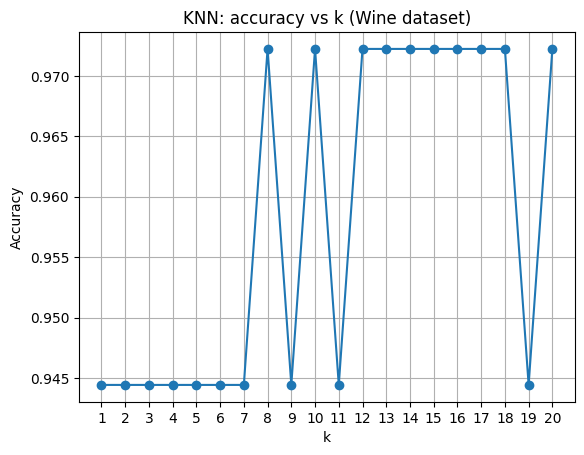

In [8]:
# График accuracy vs k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(np.mean(knn.predict(X_test_scaled) == y_test))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN: accuracy vs k (Wine dataset)')
plt.xticks(k_values)
plt.grid(True)
plt.show()